<a href="https://colab.research.google.com/github/sma-rajaei/Titanic-Classification/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import necessary libraries
#Perform initial data exploration and analyze missing values

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from zlib import crc32
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import  RandomForestClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator
from sklearn.base import TransformerMixin
from sklearn.utils.validation import check_array ,check_is_fitted
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.model_selection import cross_val_score

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Titanic-Dataset.csv")

In [146]:
print(df.info())
print(df.corr(numeric_only=True))
print("\nDescriptive Statistics:")
print(df.describe())
print("\nMissing Values Count:")
print(df.isnull().sum())
print("\nNumber of Unique Values per Column:")
print(df.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclas

# Visualize feature relationships with the target variable

<Axes: xlabel='Parch', ylabel='Count'>

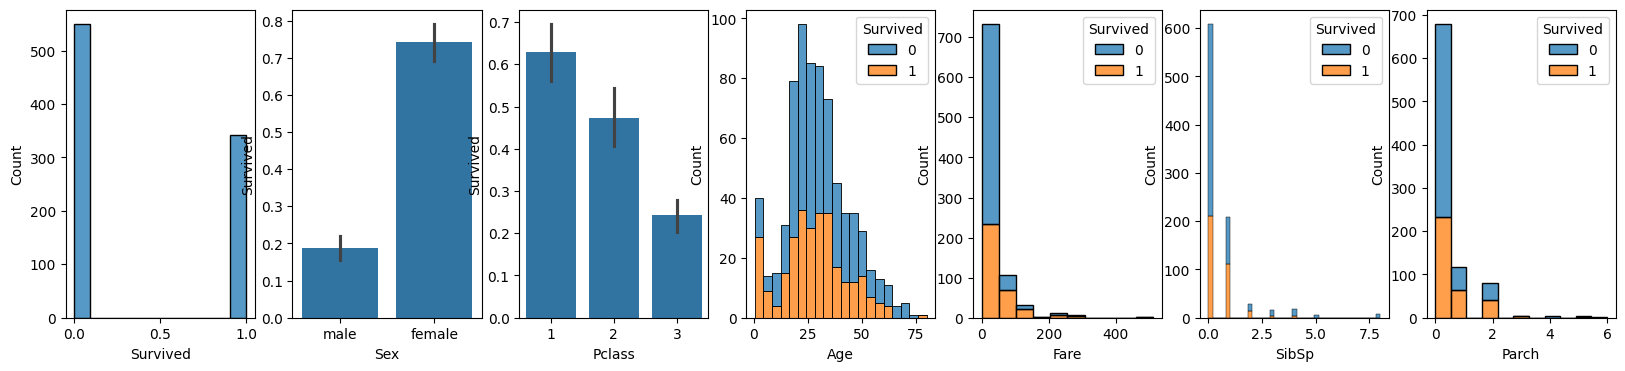

In [102]:

fig, axes = plt.subplots(1, 7, figsize=(20, 4))
sns.histplot(data = df , x = "Survived" , ax = axes[0])
sns.barplot(data = df , x = "Sex",y="Survived", ax = axes[1])
sns.barplot(data=df,x="Pclass",y="Survived",ax = axes[2])
sns.histplot(data=df, x="Age", hue="Survived",multiple="stack", ax =axes[3])
sns.histplot(data=df, x="Fare", hue="Survived",multiple="stack", ax =axes[4],bins = 10)
sns.histplot(data=df, x="SibSp", hue="Survived",multiple="stack", ax =axes[5])
sns.histplot(data=df, x="Parch", hue="Survived", multiple="stack",ax =axes[6])

# Visualize feature relationships with the target variable


In [103]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
print(df.info())
df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
print(df["Title"].value_counts())
title_mapping = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
}
df["Title"] = df["Title"].replace(title_mapping)
main_titles = ["Mr", "Miss", "Mrs", "Master"]
df["Title"][~df["Title"].isin(main_titles)] = "Rare"
print(df["Title"].value_counts(),"\n",df.info())
df.drop(columns=["PassengerId","Name","Ticket","SibSp","Parch","Cabin"],inplace = True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  FamilySize   891 non-null    int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 90.6+ KB
None
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1

<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:3: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1755/443185703.py:3: SyntaxWarning: invalid escape sequence '\.'
  df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
/tmp/ipykernel_1755/443185703.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pan

# train/test and  X/y   Split
#Categorical and Numerical Features Split, Encoding And Pipeline





In [104]:
X = df.drop(columns = "Survived")
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state=22,stratify=y)

In [105]:
numericalFeatures = list(X_train.select_dtypes(include=[np.number]).columns)
categoricalFeatures = ["Sex","Embarked","Title"]
numreicalFeaturesPipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="median"))
])
CategoricalPipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("ohe",OneHotEncoder())
])
Preprocessor = ColumnTransformer([
    ("numerical",numreicalFeaturesPipeline,numericalFeatures),
    ("categorical",CategoricalPipeline,categoricalFeatures)
])
X_train_prepared = Preprocessor.fit_transform(X_train)
X_train_prepared = pd.DataFrame(X_train_prepared,columns=Preprocessor.get_feature_names_out())
X_train_prepared.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   numerical__Pclass          712 non-null    float64
 1   numerical__Age             712 non-null    float64
 2   numerical__Fare            712 non-null    float64
 3   numerical__FamilySize      712 non-null    float64
 4   categorical__Sex_female    712 non-null    float64
 5   categorical__Sex_male      712 non-null    float64
 6   categorical__Embarked_C    712 non-null    float64
 7   categorical__Embarked_Q    712 non-null    float64
 8   categorical__Embarked_S    712 non-null    float64
 9   categorical__Title_Master  712 non-null    float64
 10  categorical__Title_Miss    712 non-null    float64
 11  categorical__Title_Mr      712 non-null    float64
 12  categorical__Title_Mrs     712 non-null    float64
 13  categorical__Title_Rare    712 non-null    float64

#Baseline models with preprocessing pipeline and evaluation



In [141]:
#1. Logistic Regression
lgRegressionPipeline = Pipeline([
    ("preprocessor",Preprocessor),
    ("model",LogisticRegression())
])
lgRegressionPipeline.fit(X_train,y_train)
y_pred = lgRegressionPipeline.predict(X_train)
print("Accuracy Score: ",cross_val_score(lgRegressionPipeline,X_train,y_train,cv=5,scoring="accuracy").mean()
,"\nConfusion Matrix : ",confusion_matrix(y_train, y_pred),
"\n Precision Score: ",precision_score(y_train,y_pred),"\n Recall Score : ",recall_score(y_train,y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Accuracy Score:  0.8286614793657048 
Confusion Matrix :  [[388  51]
 [ 69 204]] 
 Precision Score:  0.8 
 Recall Score :  0.7472527472527473


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [107]:
#2. DecisionTree Classification
dtClassificationPipeline = Pipeline([
    ("preprocessor",Preprocessor),
    ("model",DecisionTreeClassifier(random_state=22))
])
dtClassifierPipeline.fit(X_train,y_train)
y_pred = dtClassifierPipeline.predict(X_test)
print("Accuracy : ",cross_val_score(dtClassifierPipeline,X_train,y_train,cv=5,scoring="accuracy").mean()
,"\nConfusion Matrix : \n",confusion_matrix(y_test,y_pred),"\nPrecision: ",precision_score(y_test,y_pred),"\nRecall :",recall_score(y_test,y_pred))

Accuracy :  0.7850881512853343 
Confusion Matrix : 
 [[90 20]
 [24 45]] 
Precision:  0.6923076923076923 
Recall : 0.6521739130434783


In [110]:
#3. RandomForest Classification
rfClassificationPipeline = Pipeline([
    ("preprocessor",Preprocessor),
    ("model",RandomForestClassifier(random_state=22))
])
rfClassificationPipeline.fit(X_train,y_train)
y_pred = rfClassificationPipeline.predict(X_test)
print("Accuracy : ",cross_val_score(dtClassifierPipeline,X_train,y_train,cv=5,scoring="accuracy").mean()
,"\nConfusion Matrix : \n",confusion_matrix(y_test,y_pred),"\nPrecision: ",precision_score(y_test,y_pred),"\nRecall :",recall_score(y_test,y_pred))

Accuracy :  0.7850881512853343 
Confusion Matrix : 
 [[90 20]
 [19 50]] 
Precision:  0.7142857142857143 
Recall : 0.7246376811594203


# GridSearch

In [128]:
params = {
    "model__max_depth":[2,3,5,8,15],
    "model__min_samples_leaf":[2,5,10,15,28],
    "model__min_samples_split":[5,10,15,25,30]
}
gr = GridSearchCV(dtClassificationPipeline,param_grid=params,cv=5,scoring="accuracy")
gr.fit(X_train,y_train)
print("DecistionTree\n\nBest Parameters: ",gr.best_params_,"\nBest Score : ",gr.best_score_)
decisionTreeModel = gr.best_estimator_
gr = GridSearchCV(rfClassificationPipeline,param_grid=params,cv=5,scoring="accuracy")
gr.fit(X_train,y_train)
print("\n\nrandomForest\n\nBest Parameters: ",gr.best_params_,"\nBest Score : ",gr.best_score_)
randomForestModel = gr.best_estimator_

DecistionTree

Best Parameters:  {'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 15} 
Best Score :  0.834295282182606


randomForest

Best Parameters:  {'model__max_depth': 15, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10} 
Best Score :  0.852555894809416


# Final Evalution of Model With Test Data

In [142]:
y_test_pred = lgRegressionPipeline.predict(X_test)
print("LogisticRegression : \n\n","Accuracy : ",accuracy_score(y_test,y_test_pred),"\nConfusion Matrix : \n",
confusion_matrix(y_test,y_test_pred),"\nPrecision: ",precision_score(y_test,y_test_pred),"\nRecall :",recall_score(y_test,y_test_pred))

y_test_pred = decisionTreeModel.predict(X_test)
print("DecisionTreeClassifier : \n\n","Accuracy : ",accuracy_score(y_test,y_test_pred),"\nConfusion Matrix : \n",
confusion_matrix(y_test,y_test_pred),"\nPrecision: ",precision_score(y_test,y_test_pred),"\nRecall :",recall_score(y_test,y_test_pred))

y_test_pred = randomForestModel.predict(X_test)
print("\nRandomForrestClassifier : \n\n","Accuracy : ",accuracy_score(y_test,y_test_pred),
"\nConfusion Matrix : \n",confusion_matrix(y_test,y_test_pred),"\nPrecision: ",precision_score(y_test,y_test_pred),"\nRecall :",recall_score(y_test,y_test_pred))

LogisticRegression : 

 Accuracy :  0.8324022346368715 
Confusion Matrix : 
 [[99 11]
 [19 50]] 
Precision:  0.819672131147541 
Recall : 0.7246376811594203
DecisionTreeClassifier : 

 Accuracy :  0.8212290502793296 
Confusion Matrix : 
 [[98 12]
 [20 49]] 
Precision:  0.8032786885245902 
Recall : 0.7101449275362319

RandomForrestClassifier : 

 Accuracy :  0.8156424581005587 
Confusion Matrix : 
 [[96 14]
 [19 50]] 
Precision:  0.78125 
Recall : 0.7246376811594203


# Feature Importance

                      Feature  Importance
11      categorical__Title_Mr    0.526949
3       numerical__FamilySize    0.173890
0           numerical__Pclass    0.122040
2             numerical__Fare    0.072506
13    categorical__Title_Rare    0.053239
1              numerical__Age    0.043531
6     categorical__Embarked_C    0.007846
4     categorical__Sex_female    0.000000
5       categorical__Sex_male    0.000000
7     categorical__Embarked_Q    0.000000
9   categorical__Title_Master    0.000000
8     categorical__Embarked_S    0.000000
10    categorical__Title_Miss    0.000000
12     categorical__Title_Mrs    0.000000


<Axes: xlabel='Feature', ylabel='Importance'>

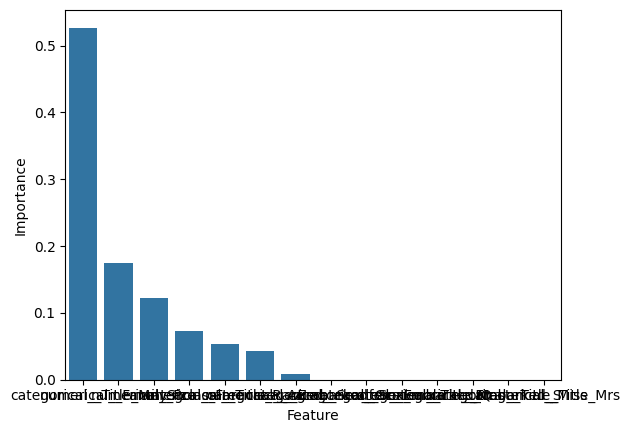

In [139]:
model = decisionTreeModel
featureNames = model["preprocessor"].get_feature_names_out()
featureImportances = model["model"].feature_importances_
featureImportance = pd.DataFrame({
    "Feature":featureNames,
    "Importance":featureImportances
})
featureImportance = featureImportance.sort_values(by="Importance",ascending=False)
print(featureImportance)
sns.barplot(data=featureImportance,x="Feature",y="Importance")

# Conclusion

In [145]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest"],
    "CV Accuracy": [0.8286614793657048,0.7850881512853343,0.7850881512853343],
    "Test Accuracy": [0.8324022346368715,0.8212290502793296,0.8156424581005587 ],
    "Precision": [0.819672131147541,0.8032786885245902,0.8156424581005587],
    "Recall": [0.7246376811594203,0.7101449275362319,0.7246376811594203]
})
results = results.sort_values(by="Test Accuracy",ascending=False)
results

,Model,CV Accuracy,Test Accuracy,Precision,Recall
0,Logistic Regression,0.828661,0.832402,0.819672,0.724638
1,Decision Tree,0.785088,0.821229,0.803279,0.710145
2,Random Forest,0.785088,0.815642,0.815642,0.724638
